# predict_mask: ฟังก์ชันแปลงภาพเป็น Binary Mask สำหรับฝั่ง IP

รับภาพ BGR (numpy array) คืนค่า Binary Mask (0/255) ขนาดเท่าภาพต้นฉบับ
ไม่ต้องเขียนโค้ด PyTorch เอง เรียกฟังก์ชันเดียวจบ

In [3]:
import os, sys
os.chdir('/home/jovyan/cardashcam_train_model')
sys.path.append('.')

import cv2
import numpy as np
import torch
import segmentation_models_pytorch as smp

IMG_SIZE = (448, 800)  # (height, width) ขนาดที่โมเดลรับ ต้องตรงกับตอนเทรน

def load_model(checkpoint_path="models/thai_ft_rh_s1_best_f1.pth", device=None):
    """โหลดโมเดล U-Net + ResNet50 จาก checkpoint เรียกครั้งเดียวตอนเริ่มโปรแกรม"""
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    else:
        device = torch.device(device)
    model = smp.Unet(encoder_name="resnet50", encoder_weights=None,
                      in_channels=3, classes=1)
    state_dict = torch.load(checkpoint_path, map_location=device, weights_only=False)
    model.load_state_dict(state_dict)
    model.to(device).eval()
    print(f"โหลดโมเดลจาก {checkpoint_path} บน {device}")
    return model, device

@torch.inference_mode()
def predict_mask(model, frame, device=None, threshold=0.5):
    """
    รับภาพ 1 เฟรม (BGR, uint8) คืนค่า Binary Mask (0/255) ขนาดเท่าภาพต้นฉบับ

    Parameters
    ----------
    model : โมเดลจาก load_model()
    frame : numpy array (H, W, 3) BGR uint8
    device : torch.device (ถ้าไม่ระบุจะดูจากโมเดล)
    threshold : เกณฑ์ตัดสิน (ค่าเริ่มต้น 0.5)

    Returns
    -------
    numpy array (H, W) uint8 ค่า 0 หรือ 255
    """
    if device is None:
        device = next(model.parameters()).device
    orig_h, orig_w = frame.shape[:2]

    # 1. Resize เป็น 448x800
    resized = cv2.resize(frame, (IMG_SIZE[1], IMG_SIZE[0]), interpolation=cv2.INTER_LINEAR)

    # 2. BGR -> RGB -> float32 [0,1] -> Tensor (C,H,W)
    rgb = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)
    tensor = torch.from_numpy(rgb).float().permute(2, 0, 1) / 255.0
    tensor = tensor.unsqueeze(0).to(device)

    # 3. Forward pass + sigmoid + threshold
    logits = model(tensor)
    prob = torch.sigmoid(logits[0, 0]).cpu().numpy()
    mask_small = (prob > threshold).astype(np.uint8) * 255

    # 4. Resize กลับขนาดเดิม (NEAREST ไม่ให้ขอบเบลอ)
    mask = cv2.resize(mask_small, (orig_w, orig_h), interpolation=cv2.INTER_NEAREST)
    return mask


## ทดสอบ: โหลดโมเดลแล้วทำนาย 1 ภาพ

In [8]:
import time

model, device = load_model()

img_path = "thai_road_lane/images/curve__Anusaowalee_curve01_0003.jpg"
frame = cv2.imread(img_path)
assert frame is not None, f"เปิดภาพไม่ได้: {img_path}"

t0 = time.time()
mask = predict_mask(model, frame, device)
t1 = time.time()

print(f"ภาพต้นฉบับ: {frame.shape[1]}x{frame.shape[0]}")
print(f"Mask ผลลัพธ์: {mask.shape[1]}x{mask.shape[0]}")
print(f"เวลา inference: {(t1-t0)*1000:.1f} ms")
print(f"จำนวน pixel เส้นเลน: {(mask == 255).sum()}")


โหลดโมเดลจาก models/thai_ft_rh_s1_best_f1.pth บน cuda
ภาพต้นฉบับ: 1920x1080
Mask ผลลัพธ์: 1920x1080
เวลา inference: 12.1 ms
จำนวน pixel เส้นเลน: 14861


## แสดงผลภาพ + Mask ซ้อนทับ

/tmp/ipykernel_2932/2455149732.py:19: UserWarning: Glyph 3616 (\N{THAI CHARACTER PHO SAMPHAO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2932/2455149732.py:19: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2932/2455149732.py:19: UserWarning: Glyph 3614 (\N{THAI CHARACTER PHO PHAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2932/2455149732.py:19: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2932/2455149732.py:19: UserWarning: Glyph 3657 (\N{THAI CHARACTER MAI THO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2932/2455149732.py:19: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2932/2455149732.py:19: UserWarning: Glyph 3593 (\N{THAI CHARACTER CHO CHING}) missing from font(s) DejaVu S

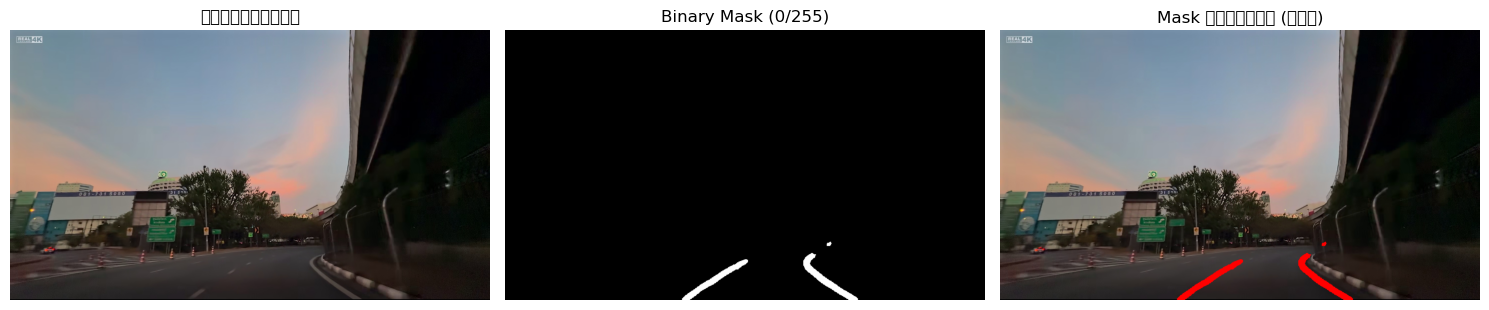

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
axes[0].set_title("ภาพต้นฉบับ")
axes[0].axis("off")

axes[1].imshow(mask, cmap="gray")
axes[1].set_title("Binary Mask (0/255)")
axes[1].axis("off")

overlay = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB).copy()
overlay[mask == 255] = [255, 0, 0]
axes[2].imshow(overlay)
axes[2].set_title("Mask ซ้อนทับ (แดง)")
axes[2].axis("off")

plt.tight_layout()
plt.show()
